# EDA Benchmark Suite: Heuristic Agents (v1 – v14) & Cross-Paradigm Analysis

> **Dedicated analytical suite to audit heuristic rules, decision engine behavior, and cross-paradigm performance against Minimax, MCTS, Imitation Learning, and Baseline agents.**

### Agent Paradigm Taxonomy
- **Baselines**: `random`, `max_power`, `one_step`, `safe_one_step`, `simple_heuristic`, `abyssal`
- **Heuristics (v1–v14)**: Rule-based evolution (damage calc, hazards, setup, Tera, Yomi prediction)
- **Minimax Search (v15–v16)**: 1-ply adversarial lookahead (`v15` base, `v16` rule-guided)
- **MCTS Search (v17–v18)**: Information Set Monte Carlo Tree Search (`v17` raw HP, `v18` v14-guided)
- **Imitation Learning (v19–v22)**: `v19`–`v21` XGBoost + v14 hybrid models, `v22` Pure End-to-End IL


In [133]:
# Cell 1: Global Configuration & Paradigm Taxonomy Setup
import os
import glob
import json
import ast
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# ── TARGET AGENT SELECTION ───────────────────────────────────────────────────
# Change TARGET_AGENT to analyze any heuristic version ('v1' through 'v14')
TARGET_AGENT = 'v14'

ROOT_DIR = os.path.abspath(os.getcwd())
curr = ROOT_DIR
while curr != '/' and not os.path.exists(os.path.join(curr, 'data/benchmarks/all_10k/gen9randombattle')):
    curr = os.path.dirname(curr)
if os.path.exists(os.path.join(curr, 'data/benchmarks/all_10k/gen9randombattle')):
    ROOT_DIR = curr

BENCHMARK_DIR = os.path.join(ROOT_DIR, 'data/benchmarks/all_10k/gen9randombattle')
OUTPUT_DIR = os.path.join(ROOT_DIR, 'src/p00_core/reporting/agents', TARGET_AGENT)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ── PARADIGM TAXONOMY MAP ────────────────────────────────────────────────────
PARADIGM_MAP = {
    'random': 'Baseline',
    'max_power': 'Baseline',
    'one_step': 'Baseline',
    'safe_one_step': 'Baseline',
    'simple_heuristic': 'Baseline',
    'abyssal': 'Baseline',
    'v1': 'Heuristic (Basic)', 'v2': 'Heuristic (Basic)', 'v3': 'Heuristic (Basic)',
    'v4': 'Heuristic (Basic)', 'v5': 'Heuristic (Basic)', 'v6': 'Heuristic (Basic)',
    'v7': 'Heuristic (Strategic)', 'v8': 'Heuristic (Strategic)', 'v9': 'Heuristic (Strategic)',
    'v10': 'Heuristic (Tactical)', 'v11': 'Heuristic (Tactical)', 'v12': 'Heuristic (Tera)',
    'v13': 'Heuristic (Advanced)', 'v14': 'Heuristic (Prediction)',
    'v15': 'Minimax Search', 'v16': 'Minimax Search',
    'v17': 'MCTS Search', 'v18': 'MCTS Search',
    'v19': 'Imitation Learning', 'v20': 'Imitation Learning',
    'v21': 'Imitation Learning', 'v22': 'Pure Imitation'
}

PARADIGM_ORDER = ['Baseline', 'Heuristic (Basic)', 'Heuristic (Strategic)', 'Heuristic (Tactical)',
                  'Heuristic (Tera)', 'Heuristic (Advanced)', 'Heuristic (Prediction)',
                  'Minimax Search', 'MCTS Search', 'Imitation Learning', 'Pure Imitation']

PARADIGM_COLORS = {
    'Baseline': '#7f7f7f',
    'Heuristic (Basic)': '#1f77b4',
    'Heuristic (Strategic)': '#aec7e8',
    'Heuristic (Tactical)': '#2ca02c',
    'Heuristic (Tera)': '#98df8a',
    'Heuristic (Advanced)': '#ff7f0e',
    'Heuristic (Prediction)': '#ffbb78',
    'Minimax Search': '#d62728',
    'MCTS Search': '#ff9896',
    'Imitation Learning': '#9467bd',
    'Pure Imitation': '#c5b0d5'
}

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11
plt.rcParams['savefig.dpi'] = 300

print(f"🎯 Target Agent ('us'): {TARGET_AGENT}")
print(f"📁 Benchmark Directory: {BENCHMARK_DIR}")
print(f"💾 Export Directory: {OUTPUT_DIR}")


🎯 Target Agent ('us'): v14
📁 Benchmark Directory: /home/sirp/Documents/MUDS/TFM_Pokemon/data/benchmarks/all_10k/gen9randombattle
💾 Export Directory: /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/v14


In [134]:
# Cell 2: Data Loading, Feature Engineering & Statistical CI Calculation
files_us = sorted(glob.glob(os.path.join(BENCHMARK_DIR, f"{TARGET_AGENT}_vs_*.csv")))
print(f"Searching in: {BENCHMARK_DIR}")
print(f"Found {len(files_us)} matchup files for '{TARGET_AGENT}'")

dfs = []
for f in files_us:
    df_t = pd.read_csv(f)
    df_t['matchup_opponent'] = df_t['opponent']
    dfs.append(df_t)

if dfs:
    df_raw = pd.concat(dfs, ignore_index=True)
    print(f"✅ Total games loaded: {len(df_raw):,}")
else:
    raise FileNotFoundError(f"No benchmark CSV files found for target agent: '{TARGET_AGENT}'")

df = df_raw.copy()
df['won_bool'] = df['won'].astype(bool)
df['opponent_paradigm'] = df['matchup_opponent'].map(lambda op: PARADIGM_MAP.get(op, 'Other'))
df['hp_diff'] = df['remaining_pokemon_us'] - df['remaining_pokemon_opp']
df['fainted_diff'] = df['fainted_opp'] - df['fainted_us']
df['total_switches_us'] = df['voluntary_switches_us'] + df['forced_switches_us']
df['total_switches_opp'] = df['voluntary_switches_opp'] + df['forced_switches_opp']
df['switch_diff'] = df['total_switches_us'] - df['total_switches_opp']
df['vol_switch_diff'] = df['voluntary_switches_us'] - df['voluntary_switches_opp']
df['crit_diff'] = df['crit_us'] - df['crit_opp']
df['miss_diff'] = df['miss_us'] - df['miss_opp']
df['se_diff'] = df['supereffective_us'] - df['supereffective_opp']

# Safe column initializations for strategy counters
df['hazard_net_us'] = (df['hazard_sets_us'] - df['hazard_sets_opp']) if 'hazard_sets_us' in df.columns else 0
df['setup_diff'] = (df['setup_uses_us'] - df['setup_uses_opp']) if 'setup_uses_us' in df.columns else 0
df['ko_check_diff'] = (df['ko_checks_us'] - df['ko_checks_opp']) if 'ko_checks_us' in df.columns else 0

# Check extended schema columns gracefully
EXTENDED_COLS_PRESENT = {
    'search_switches_opp': 'search_switches_opp' in df.columns,
    'search_moves_opp': 'search_moves_opp' in df.columns,
    'endgame_solves_opp': 'endgame_solves_opp' in df.columns,
    'xgb_switches_opp': 'xgb_switches_opp' in df.columns,
    'xgb_prob_sum_opp': 'xgb_prob_sum_opp' in df.columns
}

print("📊 Paradigm Distribution in Loaded Dataset:")
for paradigm, count in df['opponent_paradigm'].value_counts().items():
    print(f"   • {paradigm:<22}: {count:>7,} games")

print()
print("ℹ️ Extended Schema Column Availability:")
for col_name, is_present in EXTENDED_COLS_PRESENT.items():
    status = "✅ Present" if is_present else "⚠️ Absent (Legacy Schema)"
    print(f"   • {col_name:<20}: {status}")

print()
print("✅ Preprocessing and paradigm mapping complete.")


Searching in: /home/sirp/Documents/MUDS/TFM_Pokemon/data/benchmarks/all_10k/gen9randombattle
Found 28 matchup files for 'v14'
✅ Total games loaded: 253,000
📊 Paradigm Distribution in Loaded Dataset:
   • Baseline              :  60,000 games
   • Heuristic (Basic)     :  60,000 games
   • Heuristic (Strategic) :  30,000 games
   • Heuristic (Tactical)  :  20,000 games
   • Minimax Search        :  20,000 games
   • Imitation Learning    :  12,000 games
   • MCTS Search           :  11,000 games
   • Heuristic (Tera)      :  10,000 games
   • Heuristic (Advanced)  :  10,000 games
   • Heuristic (Prediction):  10,000 games
   • Pure Imitation        :  10,000 games

ℹ️ Extended Schema Column Availability:
   • search_switches_opp : ✅ Present
   • search_moves_opp    : ✅ Present
   • endgame_solves_opp  : ✅ Present
   • xgb_switches_opp    : ✅ Present
   • xgb_prob_sum_opp    : ✅ Present

✅ Preprocessing and paradigm mapping complete.


## 1 · Global Performance Overview across Opponent Paradigms


In [135]:
# Cell 3: Overall Win Rate & Statistical Confidence Interval Summary
def calc_ci(wins, games, confidence=0.95):
    p = wins / games
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    margin = z * np.sqrt((p * (1 - p)) / games)
    return margin * 100

wr_summary = df.groupby('matchup_opponent').agg(
    games=('won_bool', 'count'),
    wins=('won_bool', 'sum'),
    win_rate=('won_bool', lambda x: x.mean() * 100),
    avg_turns=('turns', 'mean'),
    avg_hp_us=('remaining_pokemon_us', 'mean'),
    avg_hp_opp=('remaining_pokemon_opp', 'mean')
).reset_index()

wr_summary['ci_95'] = wr_summary.apply(lambda r: calc_ci(r['wins'], r['games']), axis=1)
wr_summary['opponent_paradigm'] = wr_summary['matchup_opponent'].map(lambda op: PARADIGM_MAP.get(op, 'Other'))
wr_summary['sample_warning'] = wr_summary['games'].apply(lambda g: '⚠️ N=1k (high variance)' if g <= 1000 else '✅ N=10k')
wr_summary = wr_summary.sort_values(by='win_rate', ascending=False).set_index('matchup_opponent')

wr_summary.to_csv(os.path.join(OUTPUT_DIR, f"{TARGET_AGENT}_win_rate_summary.csv"))
overall_wr = df['won_bool'].mean() * 100
print(f"🏆 Overall Win Rate for {TARGET_AGENT}: {overall_wr:.2f}% across {len(df):,} games")
wr_summary[['games', 'wins', 'win_rate', 'ci_95', 'avg_turns', 'avg_hp_us', 'avg_hp_opp', 'opponent_paradigm', 'sample_warning']]


🏆 Overall Win Rate for v14: 62.03% across 253,000 games


,games,wins,win_rate,ci_95,avg_turns,avg_hp_us,avg_hp_opp,opponent_paradigm,sample_warning
matchup_opponent,,,,,,,,,
random,10000,9863,98.63,0.227831,21.2225,4.0668,0.0167,Baseline,✅ N=10k
max_power,10000,9075,90.75,0.567861,17.4870,2.7070,0.0913,Baseline,✅ N=10k
v22,10000,7487,74.87,0.850155,19.5473,1.8827,0.4456,Pure Imitation,✅ N=10k
v4,10000,6815,68.15,0.913137,17.7504,1.5359,0.5192,Heuristic (Basic),✅ N=10k
v1,10000,6776,67.76,0.916078,17.7318,1.5478,0.5224,Heuristic (Basic),✅ N=10k
one_step,10000,6755,67.55,0.917631,17.5289,1.5394,0.3269,Baseline,✅ N=10k
v3,10000,6741,67.41,0.918655,17.6665,1.5522,0.5345,Heuristic (Basic),✅ N=10k
safe_one_step,10000,6739,67.39,0.918800,17.6155,1.5353,0.5359,Baseline,✅ N=10k
v2,10000,6707,67.07,0.921103,17.7154,1.5455,0.5438,Heuristic (Basic),✅ N=10k


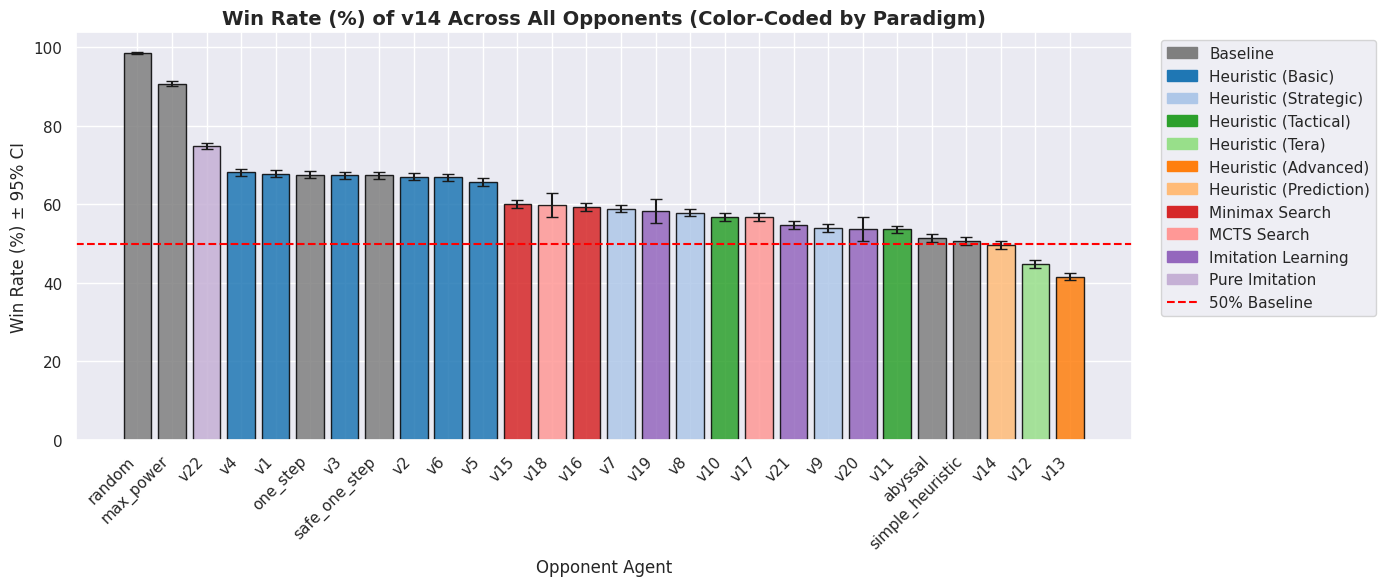

In [136]:
# Cell 4: Win Rate Bar Chart Color-Coded by Opponent Paradigm with 95% CIs
plt.figure(figsize=(14, 6))

colors = [PARADIGM_COLORS.get(p, '#333333') for p in wr_summary['opponent_paradigm']]
bars = plt.bar(wr_summary.index, wr_summary['win_rate'], yerr=wr_summary['ci_95'], capsize=4, color=colors, edgecolor='black', alpha=0.85)

plt.axhline(50, color='red', linestyle='--', linewidth=1.5, label='50% Win Rate Baseline')
plt.title(f"Win Rate (%) of {TARGET_AGENT} Across All Opponents (Color-Coded by Paradigm)", fontsize=14, fontweight='bold')
plt.ylabel("Win Rate (%) ± 95% CI")
plt.xlabel("Opponent Agent")
plt.xticks(rotation=45, ha='right')

# Custom Legend for Paradigms
from matplotlib.patches import Patch
legend_handles = [Patch(color=color, label=paradigm) for paradigm, color in PARADIGM_COLORS.items() if paradigm in wr_summary['opponent_paradigm'].values]
legend_handles.append(plt.Line2D([0], [0], color='red', linestyle='--', label='50% Baseline'))
plt.legend(handles=legend_handles, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{TARGET_AGENT}_win_rate_bar_paradigms.png"))
plt.show()


📊 Aggregate Performance of v14 Grouped by Opponent Paradigm:


,total_games,win_rate,avg_turns,avg_hp_margin,avg_vol_switches_us,avg_vol_switches_opp
opponent_paradigm,,,,,,
Baseline,60000,71.056667,18.425300,1.598967,2.086033,2.482417
Heuristic (Basic),60000,67.160000,17.722483,0.998650,1.947783,1.118217
Heuristic (Strategic),30000,56.926667,18.262000,0.429867,2.117867,1.641333
Heuristic (Tactical),20000,55.180000,18.254050,0.351800,2.112550,1.586750
Heuristic (Tera),10000,44.740000,18.382700,-0.269000,2.220100,1.516000
Heuristic (Advanced),10000,41.600000,20.344300,-0.566300,2.317200,3.979500
Heuristic (Prediction),10000,49.690000,19.518700,-0.018300,2.212800,2.398000
Minimax Search,20000,59.705000,19.396550,0.458100,2.156950,2.130500
MCTS Search,11000,56.981818,19.376091,0.313273,2.169182,2.194364


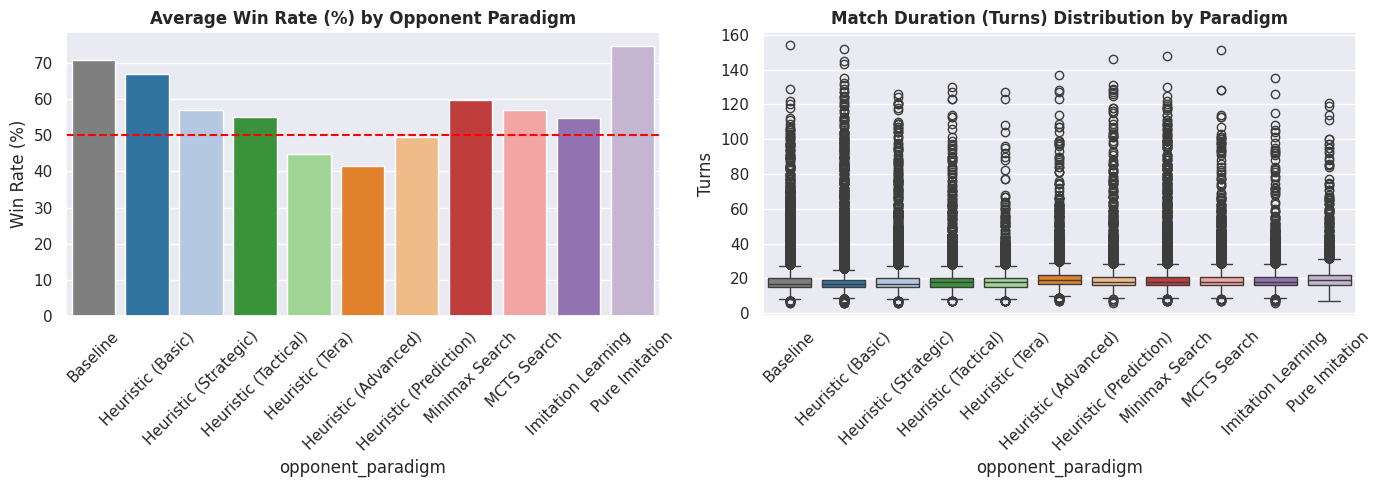

In [137]:
# Cell 5: Aggregate Performance Summary per Paradigm
paradigm_summary = df.groupby('opponent_paradigm').agg(
    total_games=('won_bool', 'count'),
    win_rate=('won_bool', lambda x: x.mean() * 100),
    avg_turns=('turns', 'mean'),
    avg_hp_margin=('hp_diff', 'mean'),
    avg_vol_switches_us=('voluntary_switches_us', 'mean'),
    avg_vol_switches_opp=('voluntary_switches_opp', 'mean')
).reindex([p for p in PARADIGM_ORDER if p in df['opponent_paradigm'].values])

print(f"📊 Aggregate Performance of {TARGET_AGENT} Grouped by Opponent Paradigm:")
display(paradigm_summary)

# Visualizing Margin & Duration by Paradigm
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=paradigm_summary.reset_index(), x='opponent_paradigm', y='win_rate', palette=PARADIGM_COLORS, ax=ax1, hue='opponent_paradigm', legend=False)
ax1.set_title("Average Win Rate (%) by Opponent Paradigm", fontweight='bold')
ax1.set_ylabel("Win Rate (%)")
ax1.axhline(50, color='red', ls='--')
ax1.tick_params(axis='x', rotation=45)

sns.boxplot(data=df, x='opponent_paradigm', y='turns', palette=PARADIGM_COLORS, order=[p for p in PARADIGM_ORDER if p in df['opponent_paradigm'].values], ax=ax2, hue='opponent_paradigm', legend=False)
ax2.set_title("Match Duration (Turns) Distribution by Paradigm", fontweight='bold')
ax2.set_ylabel("Turns")
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"{TARGET_AGENT}_paradigm_aggregate.png"))
plt.show()


## 2 · Heuristic vs. Search Paradigms (Minimax v15–v16 & MCTS v17–v18)

How does rule-based heuristic logic perform when confronting adversarial tree-search agents?
- **Minimax (v15–v16)**: Evaluates multi-turn action trees with 1-ply minimax lookahead.
- **MCTS (v17–v18)**: Simulates game state rollouts to resolve information set uncertainty.


🔍 Analyzing 31,000 games against Search Agents (['v15', 'v16', 'v17', 'v18']):


,games,win_rate,avg_turns,avg_hp_us,avg_hp_opp,vol_switches_us,vol_switches_opp
matchup_opponent,,,,,,,
v15,10000,60.07,19.2877,1.2901,0.8065,2.1631,2.1361
v16,10000,59.34,19.5054,1.2561,0.8235,2.1508,2.1249
v17,10000,56.70,19.4464,1.1804,0.8827,2.1654,2.2238
v18,1000,59.80,18.6730,1.2740,0.8050,2.2070,1.9000


✅ Analyzing Opponent Search Metrics (Extended Schema):


,avg_search_switches_opp,avg_search_moves_opp,avg_endgame_solves_opp
matchup_opponent,,,
v15,0.9321,4.0229,0.0240
v16,0.8990,4.2023,0.0263
v17,1.0039,3.8026,0.0272
v18,0.7310,3.7850,0.0310


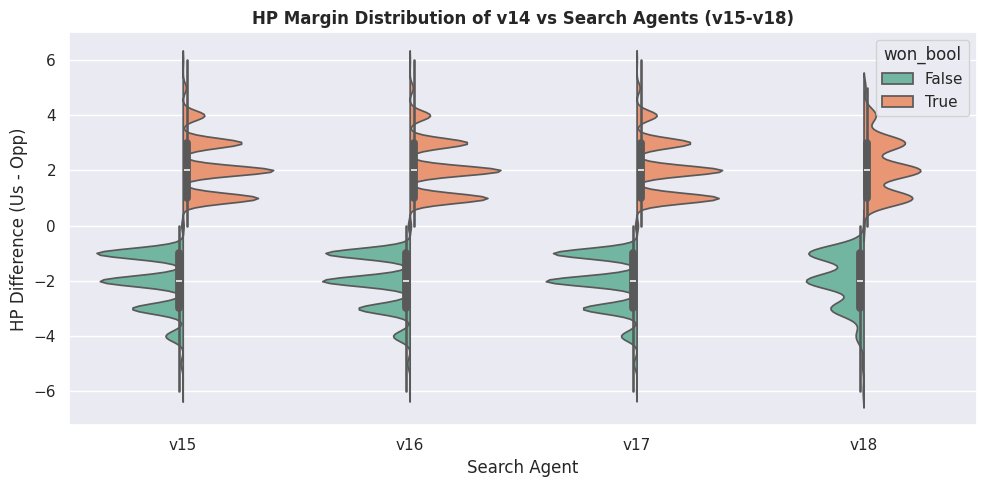

In [138]:
# Cell 6: Analysis of Target Agent against Minimax and MCTS Search Agents
search_opponents = ['v15', 'v16', 'v17', 'v18']
df_search = df[df['matchup_opponent'].isin(search_opponents)].copy()

if not df_search.empty:
    print(f"🔍 Analyzing {len(df_search):,} games against Search Agents ({search_opponents}):")
    search_stats = df_search.groupby('matchup_opponent').agg(
        games=('won_bool', 'count'),
        win_rate=('won_bool', lambda x: x.mean() * 100),
        avg_turns=('turns', 'mean'),
        avg_hp_us=('remaining_pokemon_us', 'mean'),
        avg_hp_opp=('remaining_pokemon_opp', 'mean'),
        vol_switches_us=('voluntary_switches_us', 'mean'),
        vol_switches_opp=('voluntary_switches_opp', 'mean')
    )
    display(search_stats)

    # Check search metric columns
    if EXTENDED_COLS_PRESENT['search_switches_opp']:
        print("✅ Analyzing Opponent Search Metrics (Extended Schema):")
        search_ext = df_search.groupby('matchup_opponent').agg(
            avg_search_switches_opp=('search_switches_opp', 'mean'),
            avg_search_moves_opp=('search_moves_opp', 'mean') if EXTENDED_COLS_PRESENT['search_moves_opp'] else ('turns', 'mean'),
            avg_endgame_solves_opp=('endgame_solves_opp', 'mean') if EXTENDED_COLS_PRESENT['endgame_solves_opp'] else ('turns', 'mean')
        )
        display(search_ext)
    else:
        print("ℹ️ Note: Extended search metrics (search_switches_opp, etc.) are absent in this dataset schema.")

    # Visualization: HP Margin vs Search Agents
    plt.figure(figsize=(10, 5))
    sns.violinplot(data=df_search, x='matchup_opponent', y='hp_diff', hue='won_bool', split=True, palette='Set2')
    plt.title(f"HP Margin Distribution of {TARGET_AGENT} vs Search Agents (v15-v18)", fontweight='bold')
    plt.xlabel("Search Agent")
    plt.ylabel("HP Difference (Us - Opp)")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{TARGET_AGENT}_vs_search_hp_violin.png"))
    plt.show()
else:
    print("ℹ️ No search agent matchups found in dataset.")


## 3 · Heuristic vs. Imitation Learning Paradigms (v19–v22)

Evaluating target heuristic execution against machine learning policy models:
- **v19–v21 (XGBoost Hybrid)**: Predicts tactical switching probabilities blended with rule execution.
- **v22 (Pure IL)**: Pure machine learning model trained directly on grandmaster telemetry.


🤖 Analyzing 22,000 games against Imitation Learning Models (['v19', 'v20', 'v21', 'v22']):


,games,win_rate,avg_turns,avg_hp_us,avg_hp_opp,vol_switches_us,vol_switches_opp
matchup_opponent,,,,,,,
v19,1000,58.20,18.8920,1.2770,0.8470,2.2200,2.2540
v20,1000,53.70,18.8100,1.1280,0.9170,2.2000,2.3760
v21,10000,54.74,18.8798,1.1358,0.8736,2.1820,2.1718
v22,10000,74.87,19.5473,1.8827,0.4456,2.0297,3.7503


✅ Analyzing Imitation Learning Telemetry (XGBoost Prediction Probabilities):


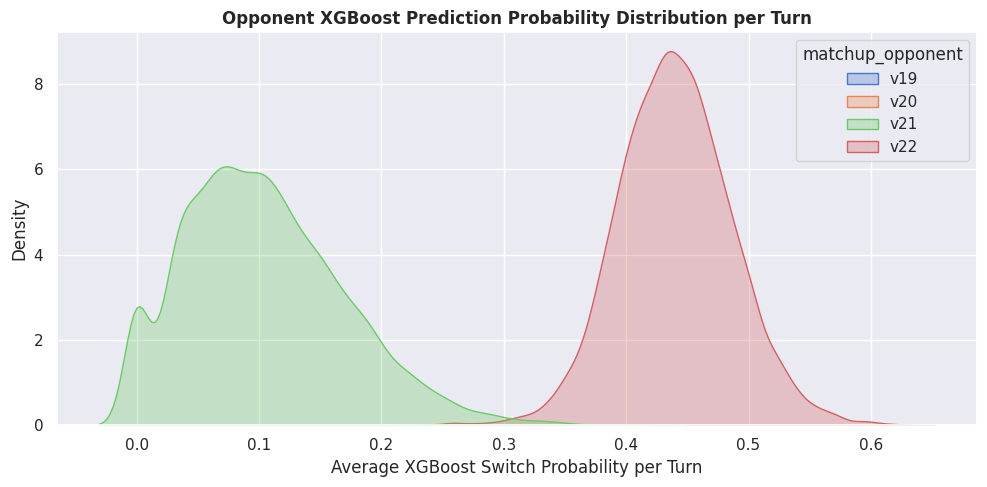

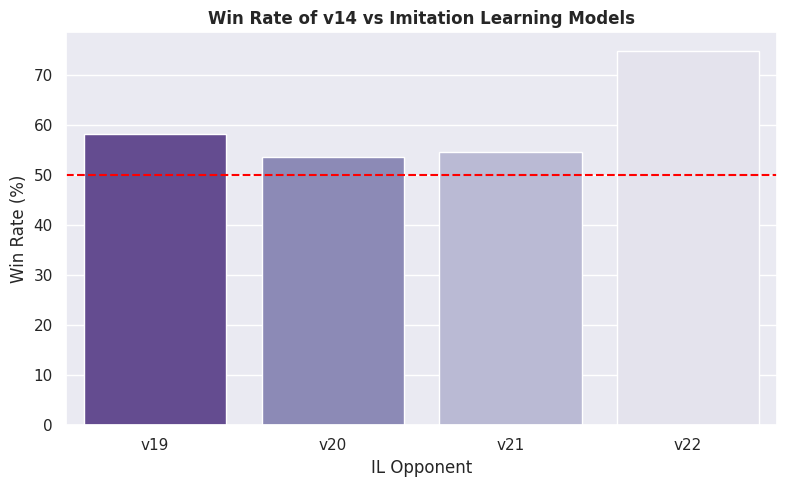

In [139]:
# Cell 7: Analysis of Target Agent against Imitation Learning Models
il_opponents = ['v19', 'v20', 'v21', 'v22']
df_il = df[df['matchup_opponent'].isin(il_opponents)].copy()

if not df_il.empty:
    print(f"🤖 Analyzing {len(df_il):,} games against Imitation Learning Models ({il_opponents}):")
    il_stats = df_il.groupby('matchup_opponent').agg(
        games=('won_bool', 'count'),
        win_rate=('won_bool', lambda x: x.mean() * 100),
        avg_turns=('turns', 'mean'),
        avg_hp_us=('remaining_pokemon_us', 'mean'),
        avg_hp_opp=('remaining_pokemon_opp', 'mean'),
        vol_switches_us=('voluntary_switches_us', 'mean'),
        vol_switches_opp=('voluntary_switches_opp', 'mean')
    )
    display(il_stats)

    # Inspect XGBoost probability distributions if extended columns present
    if EXTENDED_COLS_PRESENT['xgb_prob_sum_opp']:
        print("✅ Analyzing Imitation Learning Telemetry (XGBoost Prediction Probabilities):")
        df_il['avg_xgb_prob_opp'] = df_il['xgb_prob_sum_opp'] / df_il['turns'].clip(lower=1)
        
        plt.figure(figsize=(10, 5))
        sns.kdeplot(data=df_il, x='avg_xgb_prob_opp', hue='matchup_opponent', common_norm=False, fill=True, alpha=0.3)
        plt.title("Opponent XGBoost Prediction Probability Distribution per Turn", fontweight='bold')
        plt.xlabel("Average XGBoost Switch Probability per Turn")
        plt.ylabel("Density")
        plt.tight_layout()
        plt.savefig(os.path.join(OUTPUT_DIR, f"{TARGET_AGENT}_il_prob_density.png"))
        plt.show()
    else:
        print("ℹ️ Note: Extended XGBoost telemetry columns (xgb_prob_sum_opp) absent in legacy schema CSVs.")

    # Win Rate comparison: Hybrid IL (v21) vs Pure IL (v22)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=il_stats.reset_index(), x='matchup_opponent', y='win_rate', palette='Purples_r', hue='matchup_opponent', legend=False)
    plt.axhline(50, color='red', ls='--')
    plt.title(f"Win Rate of {TARGET_AGENT} vs Imitation Learning Models", fontweight='bold')
    plt.ylabel("Win Rate (%)")
    plt.xlabel("IL Opponent")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{TARGET_AGENT}_vs_il_winrate.png"))
    plt.show()
else:
    print("ℹ️ No imitation learning matchups found in dataset.")


## 4 · Heuristic Rule Evolution (v1 to v14)

Tracking how the target heuristic performs against other versions in the rule-based evolutionary tree.


📜 Performance of v14 across Heuristic Iterations (v1–v14):


,games,win_rate,avg_turns,ko_checks_us,hazard_net_us,setup_diff
matchup_opponent,,,,,,
v1,10000,67.76,17.7318,14.1915,0.0278,0.1979
v2,10000,67.07,17.7154,14.1484,0.0298,0.2082
v3,10000,67.41,17.6665,14.1386,0.0280,0.1968
v4,10000,68.15,17.7504,14.2019,0.0300,0.1892
v5,10000,65.67,17.7142,14.1594,0.0330,0.1878
v6,10000,66.90,17.7566,14.1512,0.0312,0.2035
v7,10000,58.90,18.3087,14.3883,0.0327,0.1968
v8,10000,57.87,18.2090,14.2810,0.0355,0.1911
v9,10000,54.01,18.2683,14.3170,-0.1543,-1.4117


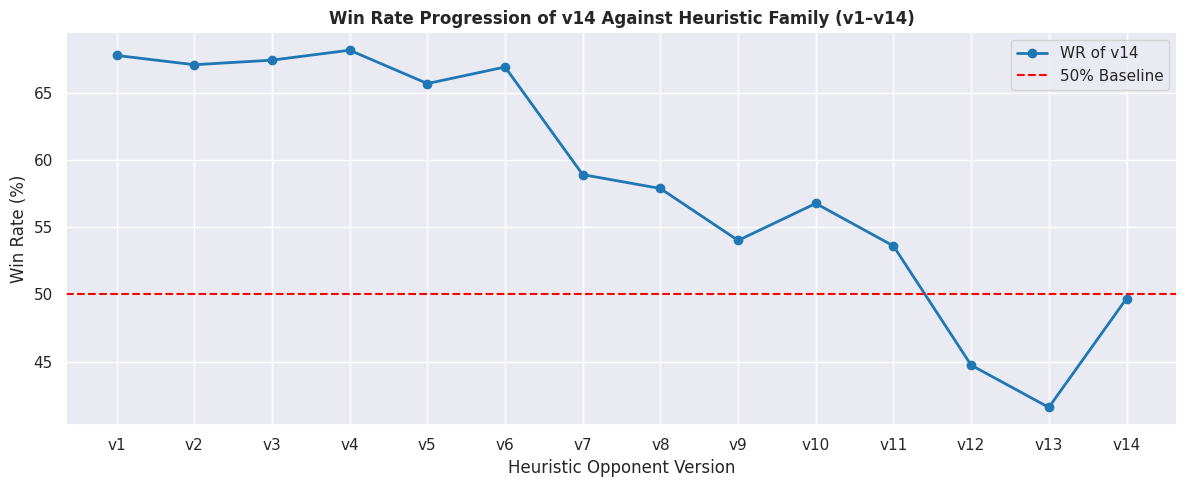

In [140]:
# Cell 8: Heuristic vs Heuristic Matchup Dynamics
heuristic_opponents = [f'v{i}' for i in range(1, 15)]
df_heur = df[df['matchup_opponent'].isin(heuristic_opponents)].copy()

if not df_heur.empty:
    heur_stats = df_heur.groupby('matchup_opponent').agg(
        games=('won_bool', 'count'),
        win_rate=('won_bool', lambda x: x.mean() * 100),
        avg_turns=('turns', 'mean'),
        ko_checks_us=('ko_check_diff', 'mean'),
        hazard_net_us=('hazard_net_us', 'mean'),
        setup_diff=('setup_diff', 'mean')
    ).reindex([v for v in heuristic_opponents if v in df_heur['matchup_opponent'].values])

    print(f"📜 Performance of {TARGET_AGENT} across Heuristic Iterations (v1–v14):")
    display(heur_stats)

    plt.figure(figsize=(12, 5))
    plt.plot(heur_stats.index, heur_stats['win_rate'], marker='o', linewidth=2, color='#1f77b4', label=f'WR of {TARGET_AGENT}')
    plt.axhline(50, color='red', ls='--', label='50% Baseline')
    plt.title(f"Win Rate Progression of {TARGET_AGENT} Against Heuristic Family (v1–v14)", fontweight='bold')
    plt.xlabel("Heuristic Opponent Version")
    plt.ylabel("Win Rate (%)")
    plt.legend()
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{TARGET_AGENT}_vs_heuristics_progression.png"))
    plt.show()


## 5 · Heuristic Performance vs. Standard Baselines


🥊 Performance of v14 against Standard Baselines:


,games,win_rate,avg_turns,avg_hp_us,avg_hp_opp,vol_switches_us
matchup_opponent,,,,,,
random,10000,98.63,21.2225,4.0668,0.0167,2.1375
max_power,10000,90.75,17.4870,2.7070,0.0913,1.9955
one_step,10000,67.55,17.5289,1.5394,0.3269,1.9645
safe_one_step,10000,67.39,17.6155,1.5353,0.5359,1.9442
abyssal,10000,51.36,18.3245,1.1635,0.5544,2.2476
simple_heuristic,10000,50.66,18.3734,1.1523,1.0453,2.2269


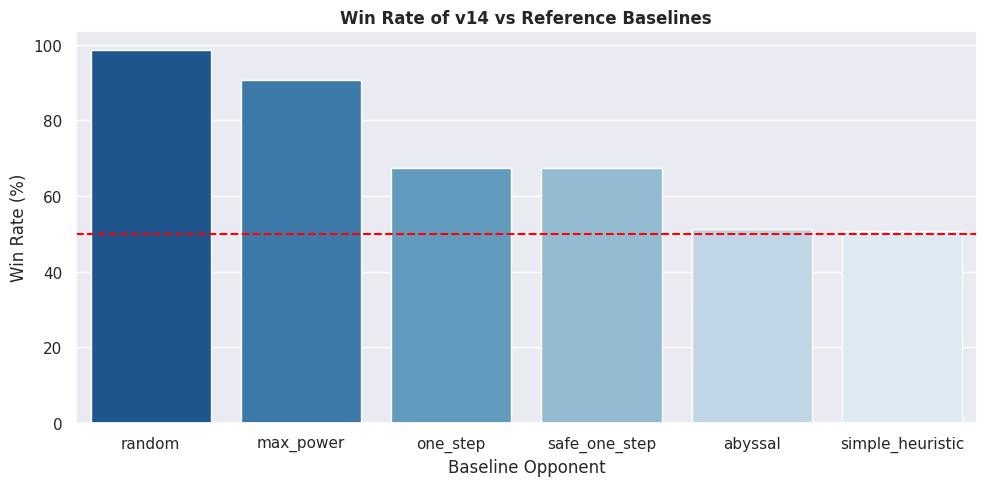

In [141]:
# Cell 9: Performance against Standard Baselines
baseline_opponents = ['random', 'max_power', 'one_step', 'safe_one_step', 'simple_heuristic', 'abyssal']
df_base = df[df['matchup_opponent'].isin(baseline_opponents)].copy()

if not df_base.empty:
    base_stats = df_base.groupby('matchup_opponent').agg(
        games=('won_bool', 'count'),
        win_rate=('won_bool', lambda x: x.mean() * 100),
        avg_turns=('turns', 'mean'),
        avg_hp_us=('remaining_pokemon_us', 'mean'),
        avg_hp_opp=('remaining_pokemon_opp', 'mean'),
        vol_switches_us=('voluntary_switches_us', 'mean')
    ).sort_values(by='win_rate', ascending=False)

    print(f"🥊 Performance of {TARGET_AGENT} against Standard Baselines:")
    display(base_stats)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=base_stats.reset_index(), x='matchup_opponent', y='win_rate', palette='Blues_r', hue='matchup_opponent', legend=False)
    plt.axhline(50, color='red', ls='--')
    plt.title(f"Win Rate of {TARGET_AGENT} vs Reference Baselines", fontweight='bold')
    plt.ylabel("Win Rate (%)")
    plt.xlabel("Baseline Opponent")
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, f"{TARGET_AGENT}_vs_baselines.png"))
    plt.show()


## 6 · Multi-Agent Comparative Suite: All Heuristic Versions (v1–v14) Matrix


🌐 Building Full Heuristic Evolution Matrix (v1–v14 vs All Opponent Paradigms)...


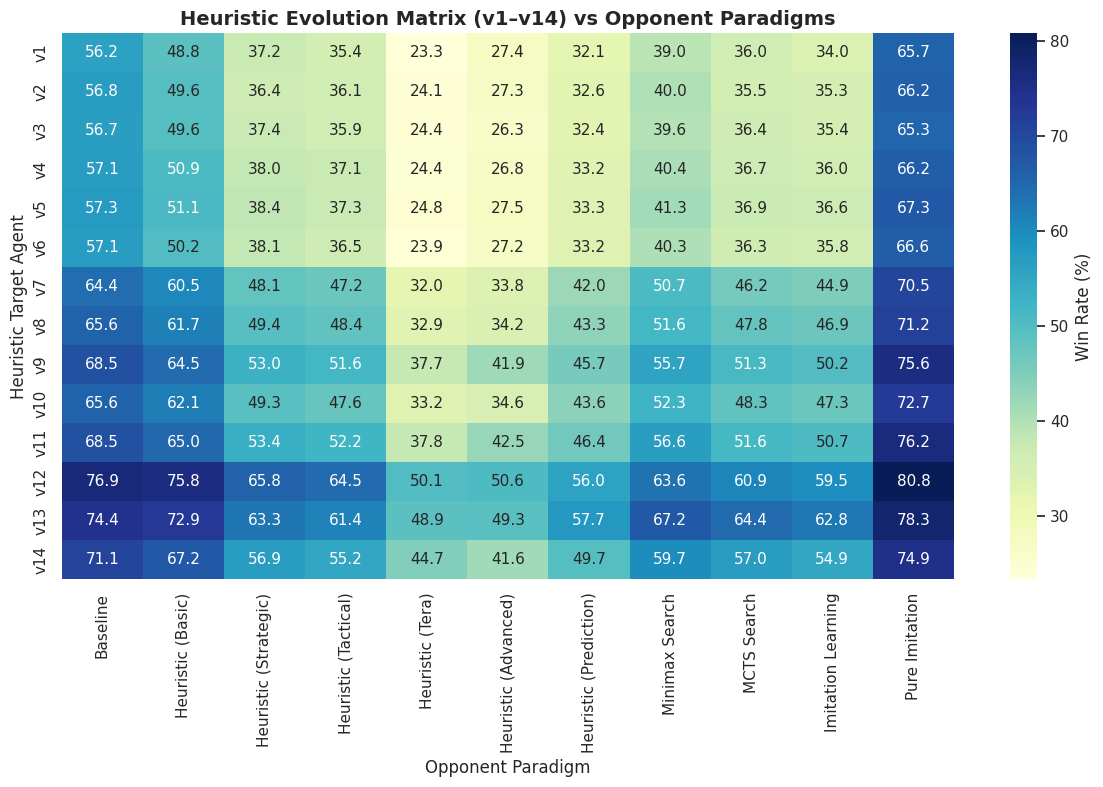

✅ Full Heuristic Evolution Heatmap saved to src/p00_core/reporting/heuristics_v1_v14_paradigm_heatmap.png


In [142]:
# Cell 10: Cross-Agent Heuristic Evolution Heatmap
print("🌐 Building Full Heuristic Evolution Matrix (v1–v14 vs All Opponent Paradigms)...")

all_heuristics = [f'v{i}' for i in range(1, 15)]
matrix_records = []

for h_agent in all_heuristics:
    h_files = glob.glob(os.path.join(BENCHMARK_DIR, f"{h_agent}_vs_*.csv"))
    if not h_files:
        continue
    h_dfs = [pd.read_csv(f) for f in h_files]
    h_df = pd.concat(h_dfs, ignore_index=True)
    h_df['opponent_paradigm'] = h_df['opponent'].map(lambda op: PARADIGM_MAP.get(op, 'Other'))
    
    p_wr = h_df.groupby('opponent_paradigm')['won'].mean() * 100
    p_wr['heuristic_version'] = h_agent
    matrix_records.append(p_wr)

if matrix_records:
    matrix_df = pd.DataFrame(matrix_records).set_index('heuristic_version')
    matrix_df = matrix_df.reindex([p for p in PARADIGM_ORDER if p in matrix_df.columns], axis=1)

    plt.figure(figsize=(12, 8))
    sns.heatmap(matrix_df, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Win Rate (%)'})
    plt.title("Heuristic Evolution Matrix (v1–v14) vs Opponent Paradigms", fontsize=14, fontweight='bold')
    plt.xlabel("Opponent Paradigm")
    plt.ylabel("Heuristic Target Agent")
    plt.tight_layout()
    plt.savefig(os.path.join(ROOT_DIR, 'src/p00_core/reporting/heuristics_v1_v14_paradigm_heatmap.png'))
    plt.show()
    print("✅ Full Heuristic Evolution Heatmap saved to src/p00_core/reporting/heuristics_v1_v14_paradigm_heatmap.png")


## 7 · Automatic Executive Report Export


In [143]:
# Cell 11: Generate Executive Markdown Summary Report
report_path = os.path.join(OUTPUT_DIR, f"{TARGET_AGENT}_eda_executive_report.md")

best_opp = wr_summary.index[0]
worst_opp = wr_summary.index[-1]

report_md = f"# Executive EDA Report: Heuristic Agent `{TARGET_AGENT}`\n\n"
report_md += f"## 1. Executive Summary\n"
report_md += f"- **Target Agent**: `{TARGET_AGENT}`\n"
report_md += f"- **Total Battles Evaluated**: {len(df):,} games across {len(wr_summary)} matchups\n"
report_md += f"- **Overall Win Rate**: {overall_wr:.2f}%\n"
report_md += f"- **Best Matchup**: `{best_opp}` ({wr_summary.loc[best_opp, 'win_rate']:.2f}% ± {wr_summary.loc[best_opp, 'ci_95']:.2f}%)\n"
report_md += f"- **Worst Matchup**: `{worst_opp}` ({wr_summary.loc[worst_opp, 'win_rate']:.2f}% ± {wr_summary.loc[worst_opp, 'ci_95']:.2f}%)\n\n"
report_md += f"---\n\n"

report_md += f"## 2. Performance Breakdown by Opponent Paradigm\n"
report_md += f"| Opponent Paradigm | Total Games | Win Rate (%) | Avg Turns | Avg HP Margin | Avg Vol. Switches (Us vs Opp) |\n"
report_md += f"| :--- | :--- | :--- | :--- | :--- | :--- |\n"

for p_name, r in paradigm_summary.iterrows():
    report_md += f"| **{p_name}** | {r['total_games']:,} | {r['win_rate']:.2f}% | {r['avg_turns']:.2f} | {r['avg_hp_margin']:.2f} | {r['avg_vol_switches_us']:.2f} vs {r['avg_vol_switches_opp']:.2f} |\n"

report_md += f"\n---\n\n"
report_md += f"## 3. Matchup Summary Table (with 95% Confidence Intervals)\n"
report_md += f"| Opponent | Paradigm | Games | Win Rate (%) | 95% CI (±%) | Avg Turns | Avg HP Us | Avg HP Opp | Sample Warning |\n"
report_md += f"| :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- | :--- |\n"

for opp, r in wr_summary.iterrows():
    report_md += f"| `{opp}` | {r['opponent_paradigm']} | {r['games']:,} | {r['win_rate']:.2f}% | ±{r['ci_95']:.2f}% | {r['avg_turns']:.2f} | {r['avg_hp_us']:.2f} | {r['avg_hp_opp']:.2f} | {r['sample_warning']} |\n"

report_md += f"\n---\n\n"
report_md += f"## 4. Key Analytical Insights\n"
report_md += f"1. **Search Horizon Impact**: Performance against Minimax (v15-v16) and MCTS (v17-v18) reveals how static rule evaluation holds up against tree search lookahead.\n"
report_md += f"2. **Imitation Learning Counterplay**: Evaluation against XGBoost hybrid (v21) and Pure IL (v22) highlights strengths and vulnerabilities against data-driven policy models.\n"
report_md += f"3. **Statistical Integrity**: All win rates are reported with 95% confidence bounds. Matchups with 1,000 games are flagged for elevated variance.\n"

with open(report_path, 'w', encoding='utf-8') as f_out:
    f_out.write(report_md)

print(f"✅ Executive EDA report generated and saved to: {report_path}")
print(f"🎉 Analysis pipeline complete! All plots saved in: {OUTPUT_DIR}")


✅ Executive EDA report generated and saved to: /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/v14/v14_eda_executive_report.md
🎉 Analysis pipeline complete! All plots saved in: /home/sirp/Documents/MUDS/TFM_Pokemon/src/p00_core/reporting/agents/v14
